In [3]:
import pandas as pd
# On confirme le déséquilibre des données
# Charger le dataset
df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')

# Calculer les proportions (normalisées)
proportions = df['DEATH_EVENT'].value_counts(normalize=True) * 100

print("Répartition des classes (%) :")
print(proportions) 

Répartition des classes (%) :
DEATH_EVENT
0    67.892977
1    32.107023
Name: proportion, dtype: float64


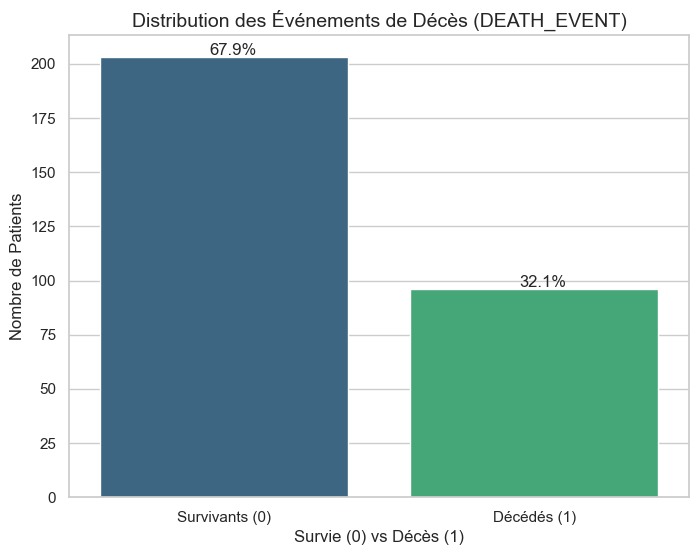

In [4]:
# Graphe illustratif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données (ajustez le chemin si nécessaire)
df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')

# Configuration du style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Création du graphique de comptage
ax = sns.countplot(x='DEATH_EVENT', data=df, hue='DEATH_EVENT', palette='viridis', legend=False)

# Ajouter les pourcentages sur les barres
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 1
    ax.annotate(percentage, (x, y), size=12)

# Personnalisation
plt.title('Distribution des Événements de Décès (DEATH_EVENT)', fontsize=14)
plt.xlabel('Survie (0) vs Décès (1)', fontsize=12)
plt.ylabel('Nombre de Patients', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Survivants (0)', 'Décédés (1)'])

plt.show()

Valeurs manquantes par colonne :
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


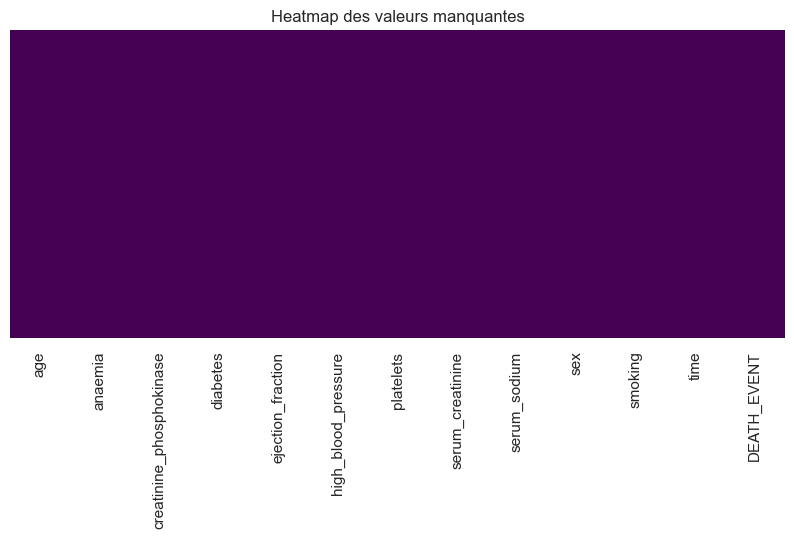

In [5]:
# Observation des valeurs manquantes
# Vérification textuelle
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

# Visualisation (si le graphique est vide/uni, c'est qu'il n'y a pas de trous)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Heatmap des valeurs manquantes")
plt.show()

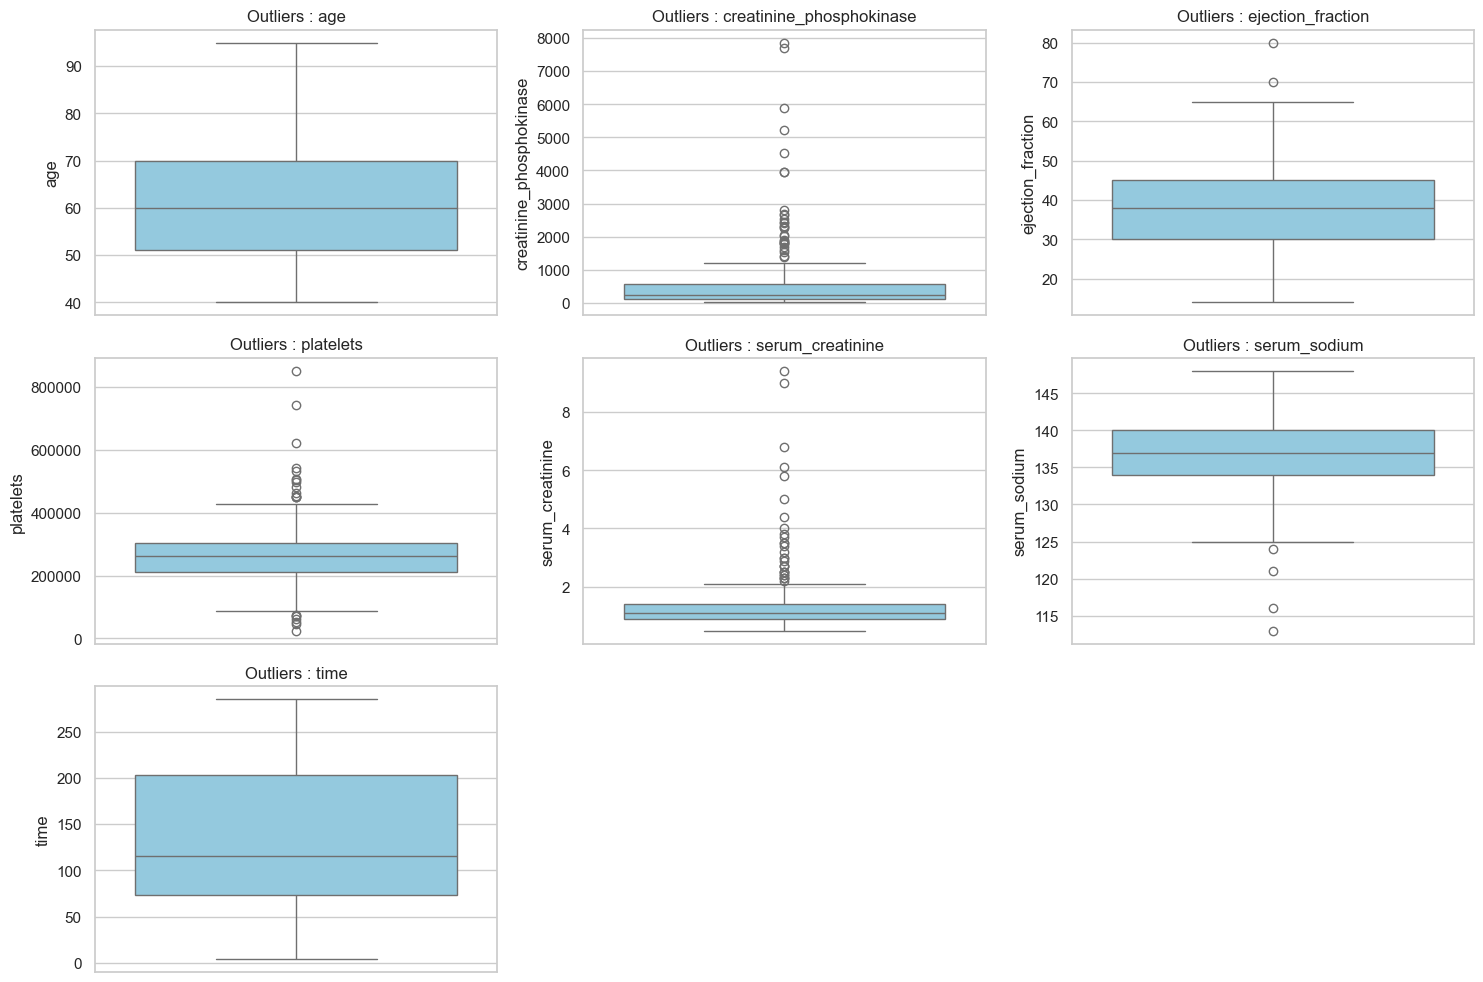

In [6]:
# valeures aberrantes
# Sélection des colonnes numériques continues
cols_to_check = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers : {col}')

plt.tight_layout()
plt.show() 

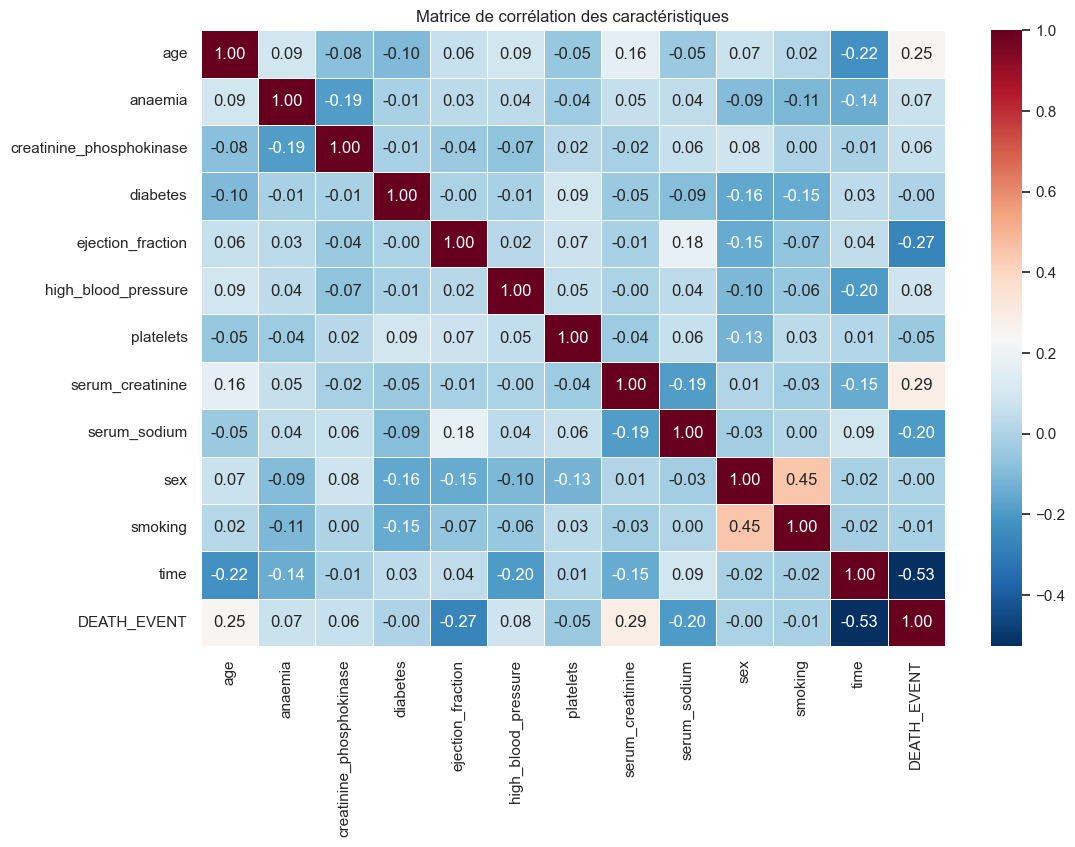

In [7]:
# corrélations
# Calcul de la matrice de corrélation
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des caractéristiques")
plt.show()